# 01 — Volatility Forecasting (Weekly)

The other weekly notebooks all target the **weekly silver log-return**. Across ARIMA,
VAR, MIDAS, RF, XGBoost, and LSTM, the best WDA we have squeezed out is ≈ 0.59–0.62
on test — meaning roughly 60 % directional accuracy on a metric weighted by absolute
move size, with the simplest models often within striking distance of the best.
Return predictability for silver is, at best, weak.

**Question for this notebook:** is **volatility** easier than direction?

Volatility clustering (Mandelbrot 1963; Engle 1982) is one of the most robust stylised
facts in financial time series — periods of high vol cluster, periods of low vol
cluster. So even when returns look like white noise, $r_t^2$ has strong autocorrelation
and is forecastable. If silver vol is forecastable, that's still a thesis-relevant
finding (vol forecasts feed risk management, option pricing, position sizing) even
when returns are not.

**Target**: weekly realised volatility from daily returns:

$$\text{RV}_t = \sqrt{\sum_{i \in \text{week } t} r_i^2}$$

**Models (escalating complexity):**

| Model | What it does | Why include it |
|---|---|---|
| Naïve | $\hat{\text{RV}}_t = \text{RV}_{t-1}$ | Floor — strong AR(1) in vol means this is hard to beat |
| HAR-RV (Corsi 2009) | Regress $\text{RV}_t$ on its 1-week / 4-week / 12-week trailing averages | Industry-standard vol benchmark |
| GARCH(1,1) | Engle-Bollerslev parametric conditional vol on weekly returns | Econometric reference |
| Random Forest | HAR features + EXOG cross-asset RVs | Tree model with same EXOG philosophy as `04_random_forest.ipynb` |
| XGBoost | Same features as RF | Aligned with `05_xgboost.ipynb` |

**Metrics:** RMSE, MAE, $R^2$ (Mincer-Zarnowitz), and **DCA** (Direction-of-Change
Accuracy on $\Delta \log \text{RV}$ — did the model correctly predict vol rising vs
falling). DA/WDA don't apply because RV ≥ 0.


## Setup

In [1]:
import sys, os
sys.path.append(os.path.abspath('../../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
from statsmodels.tsa.stattools import acf
from arch import arch_model
import warnings; warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.figsize'] = (10, 4)


## 1. Load daily data and aggregate to weekly RV

Same `train.csv / val.csv / test.csv` as every other weekly notebook. Daily silver
returns are squared, summed per W-FRI week, then square-rooted to give weekly RV.
Cross-asset RVs are computed the same way for use as EXOG features.


In [2]:
train = pd.read_csv('../../data/processed/train.csv', parse_dates=['Date']).set_index('Date')
val   = pd.read_csv('../../data/processed/val.csv',   parse_dates=['Date']).set_index('Date')
test  = pd.read_csv('../../data/processed/test.csv',  parse_dates=['Date']).set_index('Date')

ASSETS = ['silver_return', 'gold_return', 'copper_return', 'usd_return',
          'sp500_return', 'vix_return', 'oil_return']

daily = pd.concat([train[ASSETS], val[ASSETS], test[ASSETS]]).sort_index()

def weekly_rv(daily_rets):
    return np.sqrt((daily_rets ** 2).resample('W-FRI').sum())

rv = pd.concat({a.replace('_return', '_rv'): weekly_rv(daily[a]) for a in ASSETS}, axis=1)
rv = rv.dropna()
print(f'Weekly RV obs: {len(rv)}  ({rv.index.min().date()} → {rv.index.max().date()})')
rv.head()


Weekly RV obs: 592  (2015-01-09 → 2026-05-08)


,silver_rv,gold_rv,copper_rv,usd_rv,sp500_rv,vix_rv,oil_rv
Date,,,,,,,
2015-01-09,0.039710,0.021906,0.018301,0.008919,0.030649,0.203221,0.069482
2015-01-16,0.054048,0.029461,0.064370,0.004825,0.019257,0.150161,0.101212
2015-01-23,0.019898,0.015792,0.029085,0.017460,0.016872,0.158786,0.066598
2015-01-30,0.081585,0.034358,0.041376,0.010309,0.025178,0.254896,0.092746
2015-02-06,0.032449,0.026310,0.035942,0.013249,0.022479,0.172626,0.125761


## 2. EDA — autocorrelation of RV vs returns

The whole motivation for this notebook is that $r_t^2$ (and therefore RV) should be
much more autocorrelated than $r_t$ itself. If that's true on silver, vol is more
predictable than direction.


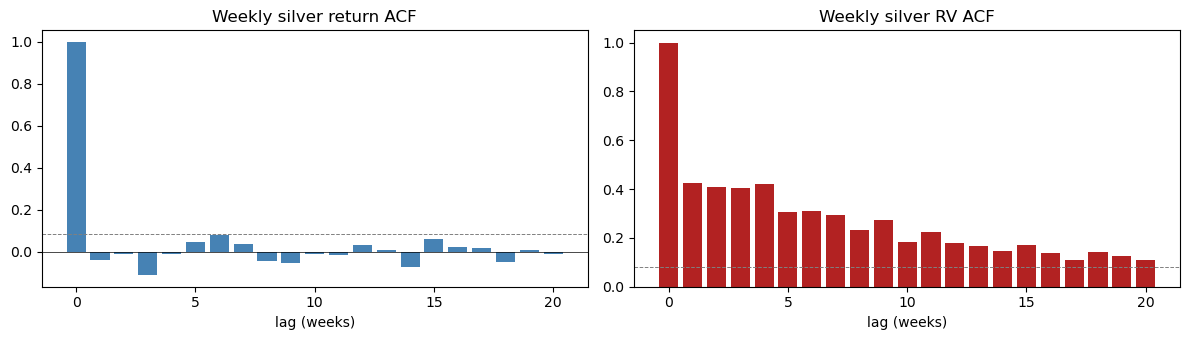

Return  ACF(1) = -0.041
RV      ACF(1) = +0.426
RV      ACF(4) = +0.422   <- multi-week persistence


In [3]:
silver_w_ret = daily['silver_return'].resample('W-FRI').sum().reindex(rv.index)
silver_rv    = rv['silver_rv']

n_lags = 20
acf_ret = acf(silver_w_ret.dropna(), nlags=n_lags, fft=True)
acf_rv  = acf(silver_rv.dropna(),    nlags=n_lags, fft=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
ax[0].bar(range(len(acf_ret)), acf_ret, color='steelblue'); ax[0].set_title('Weekly silver return ACF'); ax[0].axhline(0, color='k', lw=0.5)
ax[1].bar(range(len(acf_rv)),  acf_rv,  color='firebrick'); ax[1].set_title('Weekly silver RV ACF');     ax[1].axhline(0, color='k', lw=0.5)
for a in ax: a.set_xlabel('lag (weeks)'); a.axhline(2/np.sqrt(len(silver_rv)), color='grey', ls='--', lw=0.7)
plt.tight_layout(); plt.show()

print(f'Return  ACF(1) = {acf_ret[1]:+.3f}')
print(f'RV      ACF(1) = {acf_rv[1]:+.3f}')
print(f'RV      ACF(4) = {acf_rv[4]:+.3f}   <- multi-week persistence')


## 3. HAR features + EXOG cross-asset RVs

**HAR-RV** (Corsi 2009) regresses RV on three trailing averages that capture short /
medium / long-memory vol components:

$$\text{RV}_t = \beta_0 + \beta_w \text{RV}^{(w)}_{t-1} + \beta_m \text{RV}^{(m)}_{t-1} + \beta_q \text{RV}^{(q)}_{t-1} + \varepsilon_t$$

For our **weekly** target we use:

- $\text{RV}^{(w)}_{t-1}$ = last week's RV
- $\text{RV}^{(m)}_{t-1}$ = 4-week trailing mean (≈ 1 month)
- $\text{RV}^{(q)}_{t-1}$ = 12-week trailing mean (≈ 1 quarter)

Trees additionally get **EXOG**: 1-week lags of gold/copper/USD/S&P 500/VIX/oil RVs.


In [4]:
def har_features(rv_series):
    df = pd.DataFrame(index=rv_series.index)
    df['rv_w_lag1'] = rv_series.shift(1)
    df['rv_m_lag1'] = rv_series.shift(1).rolling(4).mean()
    df['rv_q_lag1'] = rv_series.shift(1).rolling(12).mean()
    return df

har = har_features(rv['silver_rv'])

exog_vol = pd.DataFrame(index=rv.index)
for c in rv.columns:
    if c == 'silver_rv': continue
    exog_vol[c.replace('_rv', '_rv_lag1')] = rv[c].shift(1)

frame = pd.concat([rv[['silver_rv']].rename(columns={'silver_rv': 'target'}),
                   har, exog_vol], axis=1).dropna()
print(f'Modelling frame: {len(frame)} obs, {frame.shape[1]-1} features')
frame.head()


Modelling frame: 580 obs, 9 features


,target,rv_w_lag1,rv_m_lag1,rv_q_lag1,gold_rv_lag1,copper_rv_lag1,usd_rv_lag1,sp500_rv_lag1,vix_rv_lag1,oil_rv_lag1
Date,,,,,,,,,,
2015-04-03,0.042182,0.010778,0.029519,0.038292,0.010026,0.021660,0.010662,0.016350,0.140043,0.084681
2015-04-10,0.042694,0.042182,0.033638,0.038498,0.025166,0.015996,0.011257,0.015943,0.072036,0.059034
2015-04-17,0.012582,0.042694,0.038844,0.037551,0.021050,0.020324,0.014129,0.010077,0.095041,0.098479
2015-04-24,0.028814,0.012582,0.027059,0.036942,0.011268,0.022176,0.012719,0.013421,0.157165,0.065134
2015-05-01,0.059376,0.028814,0.031568,0.032544,0.024591,0.033291,0.009486,0.011093,0.064794,0.040856


## 4. Train / val / test split

Matches the rest of the thesis: train ≤ 2021-12-31, val = 2022, test ≥ 2023-01-01.
HAR-RV is a simple OLS so train+val is treated as one for the final fit. RF/XGB use
val for hyperparameter selection.


In [5]:
TR_END   = '2021-12-31'
VAL_END  = '2022-12-31'

train_df = frame.loc[:TR_END]
val_df   = frame.loc[TR_END:VAL_END].iloc[1:]
test_df  = frame.loc[VAL_END:].iloc[1:]
trval_df = pd.concat([train_df, val_df])

print(f'train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}')

FEATS_HAR  = ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
FEATS_EXOG = [c for c in frame.columns if c.endswith('_rv_lag1') and not c.startswith('silver')]
FEATS_ALL  = FEATS_HAR + FEATS_EXOG

print('HAR  features:', FEATS_HAR)
print('EXOG features:', FEATS_EXOG)


train: 353, val: 52, test: 174
HAR  features: ['rv_w_lag1', 'rv_m_lag1', 'rv_q_lag1']
EXOG features: ['gold_rv_lag1', 'copper_rv_lag1', 'usd_rv_lag1', 'sp500_rv_lag1', 'vix_rv_lag1', 'oil_rv_lag1']


## 5. Evaluation utilities

Vol-appropriate metrics:

- **RMSE / MAE**: standard
- **$R^2$**: regression-style ($1 - \text{SSE}/\text{SST}$)
- **DCA** (Direction-of-Change Accuracy): on $\Delta \log \text{RV}_t = \log\text{RV}_t - \log\text{RV}_{t-1}$ — fraction of weeks where the model correctly predicts vol rising vs falling. This is the directional analogue of DA from the return notebooks.


In [6]:
def dca(actual, pred, prev_actual):
    """Direction-of-change accuracy on log RV change vs the previous observed RV."""
    a = np.log(actual) - np.log(prev_actual)
    p = np.log(pred)   - np.log(prev_actual)
    ok = np.isfinite(a) & np.isfinite(p)
    if ok.sum() == 0: return np.nan
    return float(np.mean(np.sign(a[ok]) == np.sign(p[ok])))

def evaluate(name, actual, pred, prev_actual):
    actual = np.asarray(actual); pred = np.asarray(pred); prev_actual = np.asarray(prev_actual)
    rmse = np.sqrt(mean_squared_error(actual, pred))
    mae  = mean_absolute_error(actual, pred)
    r2   = r2_score(actual, pred)
    d    = dca(actual, pred, prev_actual)
    print(f'{name:30s}  RMSE={rmse:.5f}  MAE={mae:.5f}  R2={r2:+.3f}  DCA={d:.3f}')
    return dict(model=name, rmse=rmse, mae=mae, r2=r2, dca=d)


## 6. Naïve baseline — $\hat{\text{RV}}_t = \text{RV}_{t-1}$

In [7]:
y_test     = test_df['target'].values
prev_test  = test_df['rv_w_lag1'].values   # = RV_{t-1}
results = []

results.append(evaluate('Naive (RV_{t-1})', y_test, prev_test, prev_test))


Naive (RV_{t-1})                RMSE=0.03990  MAE=0.02020  R2=-0.095  DCA=0.000


## 7. HAR-RV (Corsi 2009)

Pure OLS on the three HAR lags. Train+val combined.


In [8]:
import statsmodels.api as sm

X_tr = sm.add_constant(trval_df[FEATS_HAR]); y_tr = trval_df['target']
X_te = sm.add_constant(test_df[FEATS_HAR])
har_fit = sm.OLS(y_tr, X_tr).fit()
print(har_fit.summary().tables[1])

har_pred = har_fit.predict(X_te).values
results.append(evaluate('HAR-RV', y_test, har_pred, prev_test))


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0085      0.003      3.196      0.002       0.003       0.014
rv_w_lag1      0.0668      0.062      1.074      0.284      -0.056       0.189
rv_m_lag1      0.3971      0.126      3.155      0.002       0.150       0.644
rv_q_lag1      0.2799      0.129      2.173      0.030       0.027       0.533
HAR-RV                          RMSE=0.03162  MAE=0.01582  R2=+0.312  DCA=0.713


## 8. GARCH(1,1) on weekly returns

For comparison, fit a GARCH(1,1) on weekly silver log-returns. The model assumes
$r_t = \mu + \varepsilon_t,\; \varepsilon_t = \sigma_t z_t,\; \sigma_t^2 = \omega + \alpha \varepsilon_{t-1}^2 + \beta \sigma_{t-1}^2$.
We use one-step-ahead conditional vol $\hat\sigma_t$ as the prediction for $\text{RV}_t$,
re-fit walking forward week-by-week to avoid look-ahead.


In [9]:
weekly_ret = silver_w_ret.reindex(frame.index).dropna()

# Walk-forward GARCH: at each test week, refit on all prior weekly returns
garch_preds = []
test_idx = test_df.index
for d in test_idx:
    hist = weekly_ret.loc[:d].iloc[:-1]                       # data strictly before d
    m = arch_model(hist * 100, mean='Constant', vol='GARCH', p=1, q=1, dist='normal')
    res = m.fit(disp='off', show_warning=False)
    fc = res.forecast(horizon=1, reindex=False)
    sigma_t = np.sqrt(fc.variance.values[-1, 0]) / 100        # back to return scale
    garch_preds.append(sigma_t)
garch_preds = np.array(garch_preds)

results.append(evaluate('GARCH(1,1)', y_test, garch_preds, prev_test))


GARCH(1,1)                      RMSE=0.03305  MAE=0.01830  R2=+0.249  DCA=0.672


## 9. Random Forest + XGBoost

Same HAR features, plus the 6 cross-asset RV lags (EXOG). Hyperparameters tuned on
val via a small grid, then refit on train+val.


In [10]:
from sklearn.model_selection import ParameterGrid

def tune_rf(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5, None], 'min_samples_leaf': [2, 5]})
    best = (np.inf, None)
    for p in grid:
        m = RandomForestRegressor(random_state=SEED, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]: best = (rmse, p)
    return best[1]

def tune_xgb(X_tr, y_tr, X_v, y_v):
    grid = ParameterGrid({'n_estimators': [200, 400], 'max_depth': [3, 5], 'learning_rate': [0.03, 0.1]})
    best = (np.inf, None)
    for p in grid:
        m = XGBRegressor(random_state=SEED, verbosity=0, **p).fit(X_tr, y_tr)
        rmse = np.sqrt(mean_squared_error(y_v, m.predict(X_v)))
        if rmse < best[0]: best = (rmse, p)
    return best[1]

X_tr_a, y_tr_a = train_df[FEATS_ALL], train_df['target']
X_v_a,  y_v_a  = val_df[FEATS_ALL],   val_df['target']
X_tv_a         = trval_df[FEATS_ALL]; y_tv_a = trval_df['target']
X_te_a         = test_df[FEATS_ALL]

rf_best  = tune_rf (X_tr_a, y_tr_a, X_v_a, y_v_a); print('RF  best:', rf_best)
xgb_best = tune_xgb(X_tr_a, y_tr_a, X_v_a, y_v_a); print('XGB best:', xgb_best)

rf  = RandomForestRegressor(random_state=SEED, **rf_best).fit(X_tv_a, y_tv_a)
xgb = XGBRegressor(random_state=SEED, verbosity=0, **xgb_best).fit(X_tv_a, y_tv_a)

rf_pred  = rf.predict(X_te_a)
xgb_pred = xgb.predict(X_te_a)

results.append(evaluate('RF (HAR+EXOG)',  y_test, rf_pred,  prev_test))
results.append(evaluate('XGB (HAR+EXOG)', y_test, xgb_pred, prev_test))


RF  best: {'max_depth': 3, 'min_samples_leaf': 2, 'n_estimators': 200}


XGB best: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


RF (HAR+EXOG)                   RMSE=0.03522  MAE=0.01832  R2=+0.147  DCA=0.678
XGB (HAR+EXOG)                  RMSE=0.03710  MAE=0.01971  R2=+0.053  DCA=0.695


## 10. Results table

In [11]:
metrics_df = pd.DataFrame(results)
metrics_df.to_csv('../../data/processed/metrics_volatility_weekly.csv', index=False)
metrics_df.round(5)


,model,rmse,mae,r2,dca
0,Naive (RV_{t-1}),0.03990,0.02020,-0.09477,0.00000
1,HAR-RV,0.03162,0.01582,0.31239,0.71264
2,"GARCH(1,1)",0.03305,0.01830,0.24895,0.67241
3,RF (HAR+EXOG),0.03522,0.01832,0.14702,0.67816
4,XGB (HAR+EXOG),0.03710,0.01971,0.05333,0.69540


## 11. 2026 zoom — actual vs each model

Same 2026 sanity-check view as the return notebooks. Actual RV in black, each model
overlaid.


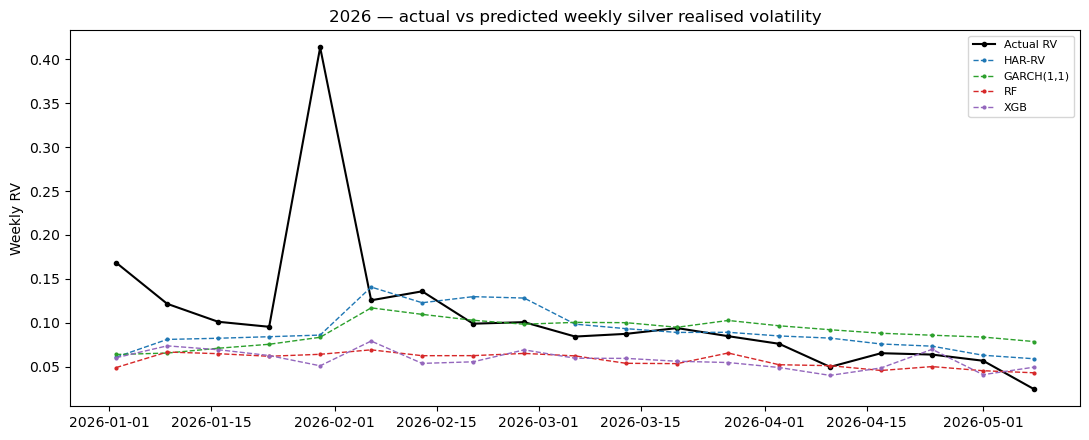

In [12]:
preds_map = {
    'Naive': prev_test,
    'HAR-RV': har_pred,
    'GARCH(1,1)': garch_preds,
    'RF': rf_pred,
    'XGB': xgb_pred,
}
df26 = pd.DataFrame({'actual': y_test, **preds_map}, index=test_df.index)
df26 = df26.loc['2026-01-01':]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(df26.index, df26['actual'], 'k-', lw=1.5, label='Actual RV', marker='o', ms=3)
for col, c in zip(['HAR-RV', 'GARCH(1,1)', 'RF', 'XGB'], ['#1f77b4', '#2ca02c', '#d62728', '#9467bd']):
    ax.plot(df26.index, df26[col], '--', lw=1, color=c, label=col, marker='.', ms=4)
ax.set_title('2026 — actual vs predicted weekly silver realised volatility')
ax.set_ylabel('Weekly RV'); ax.legend(loc='best', fontsize=8)
plt.tight_layout(); plt.show()


## 12. Conclusion (to fill in after running)

Things to look at in the metrics:

1. **Does HAR-RV beat Naïve on RMSE?** If yes, vol has predictable structure beyond a
   pure random walk. The literature consistently finds yes for equity indices and
   FX — this notebook tells you whether it holds for silver too.

2. **Does GARCH(1,1) beat HAR-RV?** GARCH is parametric and assumes Gaussian
   innovations; HAR is non-parametric on the lag structure. On weekly equity-like
   series HAR tends to win.

3. **Does adding EXOG cross-asset RVs help?** RF/XGB vs HAR-RV. If trees with EXOG
   beat HAR, that's evidence vol spills over across asset classes (gold/silver vol
   linkage, VIX as a global risk proxy).

4. **DCA**: vol rising vs falling is the trader-relevant binary. A DCA > 0.55 is
   already useful for risk-management timing decisions.

If vol turns out to be substantially more forecastable than direction (very
likely), this notebook becomes a thesis chapter in its own right: "predicting *when*
silver moves rather than *which way*". That's a defensible reframing — risk
management, options pricing, position sizing all consume volatility forecasts.
